## **geometry.py**

Detection gave us boxes. Association needs to decide which boxes belong
together and the model offers no help with that. A helmet box and a rider
box arrive as unrelated rectangles.

So the pairing has to be worked out from position alone, which means turning
each box into a number or a point that can be compared to another. That's what
this file does. Five small functions, no state, no dependencies.

The interesting part isn't the arithmetic : it's **which reference point to
use for which match**. A helmet sits at the top of a rider. A license plate
sits at the bottom of a motorcycle. Using the wrong reference point produces a
system that works most of the time and fails in ways that are hard to trace.

## **Setup**

In [1]:
!git clone -q https://github.com/shreyamali17/helmet-violation-detection.git
%cd helmet-violation-detection/project/pipeline

/content/helmet-violation-detection/project/pipeline


## **Boxes**

Every box in this pipeline is four numbers: `[x1, y1, x2, y2]` : the top-left
and bottom-right corners, in pixels.

One thing that catches people out: in image coordinates, **y increases
downwards**. `y1` is the top edge, `y2` is the bottom. A box near the top of
the frame has small y values.

In [2]:
rider = (600, 500, 660, 650)      # x1, y1, x2, y2

x1, y1, x2, y2 = rider
print(f"left edge:   x = {x1}")
print(f"right edge:  x = {x2}")
print(f"top edge:    y = {y1}   <- smaller y is higher up")
print(f"bottom edge: y = {y2}")
print()
print(f"width  = {x2 - x1} px")
print(f"height = {y2 - y1} px")

left edge:   x = 600
right edge:  x = 660
top edge:    y = 500   <- smaller y is higher up
bottom edge: y = 650

width  = 60 px
height = 150 px


## **Four reference points**

Each function collapses a box down to the one point that makes sense for a
particular kind of match.

In [3]:
def x_center(box):
    """Horizontal midpoint. Used for rider-to-motorcycle matching,
    applied to both boxes, since horizontal alignment is what matters
    there on both sides equally."""
    x1, _, x2, _ = box
    return (x1 + x2) / 2


def top_center(box):
    """Midpoint of the top edge. Used on the RIDER's box when matching
    to a helmet, because a head sits at the top of a body, not at its
    vertical center."""
    x1, y1, x2, _ = box
    return ((x1 + x2) / 2, y1)


def bottom_center(box):
    """Midpoint of the bottom edge. Used on the MOTORCYCLE's box when
    matching to a license plate, because plates are mounted low."""
    x1, _, x2, y2 = box
    return ((x1 + x2) / 2, y2)


def center(box):
    """Plain center. Used on the helmet box and the plate box - the
    'other side' of each match, where the object has no directional
    bias of its own."""
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)

### **Why not just use `center` for everything**

Because a rider's box covers a whole body. Its center sits around the torso,
which is nowhere near the head. Compare the distance from a helmet to the rider's center against the distance
to the rider's top edge.

In [4]:
rider  = (600, 500, 660, 650)
helmet = (610, 495, 650, 530)     # sitting on the rider's head

import math

def dist(p, q):
    return math.hypot(p[0] - q[0], p[1] - q[1])

h = center(helmet)

print(f"helmet center:      {h}")
print(f"rider top_center:   {top_center(rider)}   distance = {dist(h, top_center(rider)):6.1f} px")
print(f"rider plain center: {center(rider)}   distance = {dist(h, center(rider)):6.1f} px")

helmet center:      (630.0, 512.5)
rider top_center:   (630.0, 500)   distance =   12.5 px
rider plain center: (630.0, 575.0)   distance =   62.5 px


The gap matters because `HEAD_RIDER_MAX_COST` is 60 pixels. Measured from the
top edge, this helmet is comfortably inside that. Measured from the torso, it
would be rejected as too far away the rider's own helmet, thrown out.

Same logic in reverse for plates: they're mounted at the bottom of a
motorcycle, so `bottom_center` is the reference point that keeps real plates
inside the threshold.

## **Overlap**

The four functions above reduce a box to a point, which throws away its size.
For rider-to-motorcycle matching that's not good enough two objects can be
horizontally aligned and still be nowhere near each other.

IoU keeps the whole rectangle. It asks: of the total area these two boxes
cover between them, how much is shared?

$$\text{IoU} = \frac{\text{area of overlap}}{\text{area of union}}$$

The result runs from 0 (no contact) to 1 (identical boxes).

In [5]:
def iou(box_a, box_b):
    """Intersection-over-Union between two [x1,y1,x2,y2] boxes."""
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    # the overlapping rectangle: rightmost left edge, leftmost right edge
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    # max(0, ...) matters: if the boxes don't overlap, these go negative
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter

    return inter / union if union > 0 else 0.0

### **The Two Guards**

`max(0, ix2 - ix1)` : when the boxes don't touch, the "overlap" rectangle comes
out inside-out and the width goes negative. Two negatives multiplied would give a positive intersection area for boxes that never met. Clamping to zero is what makes disjoint boxes return 0.

`union - inter` : the shared region is inside both boxes, so adding the two
areas counts it twice. Subtracting it once fixes that. Skip this and IoU
under-reports on every pair.

## **Where point distance breaks**

This is the case that motivated switching rider-to-motorcycle matching from
`x_center` to `iou`.

Two objects, both roughly below the rider's horizontal position: the
motorcycle they're actually riding, and something unrelated further up the
frame.

In [7]:
rider          = (600, 500, 660, 650)
their_bike     = (590, 600, 670, 760)   # directly below - the real pair
distant_object = (610, 150, 650, 180)   # far up the frame, same x range

print("rider vs THEIR MOTORCYCLE")
print(f"  horizontal distance: {abs(x_center(rider) - x_center(their_bike)):5.1f} px")
print(f"  box overlap (IoU):   {iou(rider, their_bike):5.3f}")
print()
print("rider vs UNRELATED OBJECT")
print(f"  horizontal distance: {abs(x_center(rider) - x_center(distant_object)):5.1f} px")
print(f"  box overlap (IoU):   {iou(rider, distant_object):5.3f}")

rider vs THEIR MOTORCYCLE
  horizontal distance:   0.0 px
  box overlap (IoU):   0.160

rider vs UNRELATED OBJECT
  horizontal distance:   0.0 px
  box overlap (IoU):   0.000


Horizontal distance rates the unrelated object as the **better** match : it
happens to be more perfectly aligned left-to-right. Overlap correctly gives it
zero.

`x_center` only ever sees one number per box. It cannot tell "directly below
the rider" from "two hundred pixels up the frame," because it never looks at
y at all.

`x_center` is still in the file, but only so the two methods can be compared
side by side in the association stage. It isn't the default anymore.

## **Seeing overlap change**

Slide one box across another and watch IoU respond.

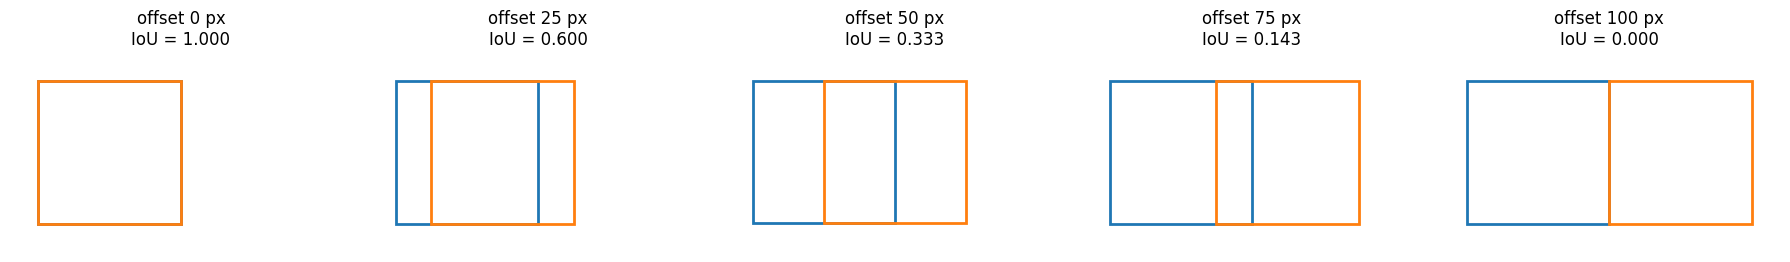

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fixed = (0, 0, 100, 100)
offsets = [0, 25, 50, 75, 100]

fig, axes = plt.subplots(1, len(offsets), figsize=(18, 4))

for ax, dx in zip(axes, offsets):
    moving = (dx, 0, dx + 100, 100)
    score = iou(fixed, moving)

    ax.add_patch(patches.Rectangle((0, 0), 100, 100,
                 fill=False, edgecolor="tab:blue", lw=2))
    ax.add_patch(patches.Rectangle((dx, 0), 100, 100,
                 fill=False, edgecolor="tab:orange", lw=2))

    ax.set_xlim(-20, 220)
    ax.set_ylim(-20, 120)
    ax.set_aspect("equal")
    ax.set_title(f"offset {dx} px\nIoU = {score:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Note it isn't linear. Shifting by half the box width drops IoU to 0.33, not
0.5 because the union grows at the same time the intersection shrinks.

That's why `RIDER_MOTO_MAX_COST = 0.9`, meaning a 0.1 IoU floor, is a looser
requirement than it sounds. A rider's box and their motorcycle's box overlap
only partially even when the pairing is obviously correct.

## Try it

- Change `helmet` so it sits at the rider's waist instead of their head. Does
  `top_center` still rate it as close?
- Make two boxes that share an edge but no area. What does `iou` return, and
  is that the answer you want?
- A small box entirely inside a large one: what's the IoU? Is that a good
  measure of "these belong together"?

That last one is worth sitting with. A helmet is entirely inside a rider's
box, and IoU would be low because the areas are so different which is
exactly why helmet matching uses point distance rather than overlap.